# CodeCarbon vs CodeGreen Comparison

This notebook compares the energy and power measurements of CodeCarbon and CodeGreen for the `instances_inference` task.
It reads the log files generated by both libraries and plots the timeseries data for CPU, GPU, and RAM.

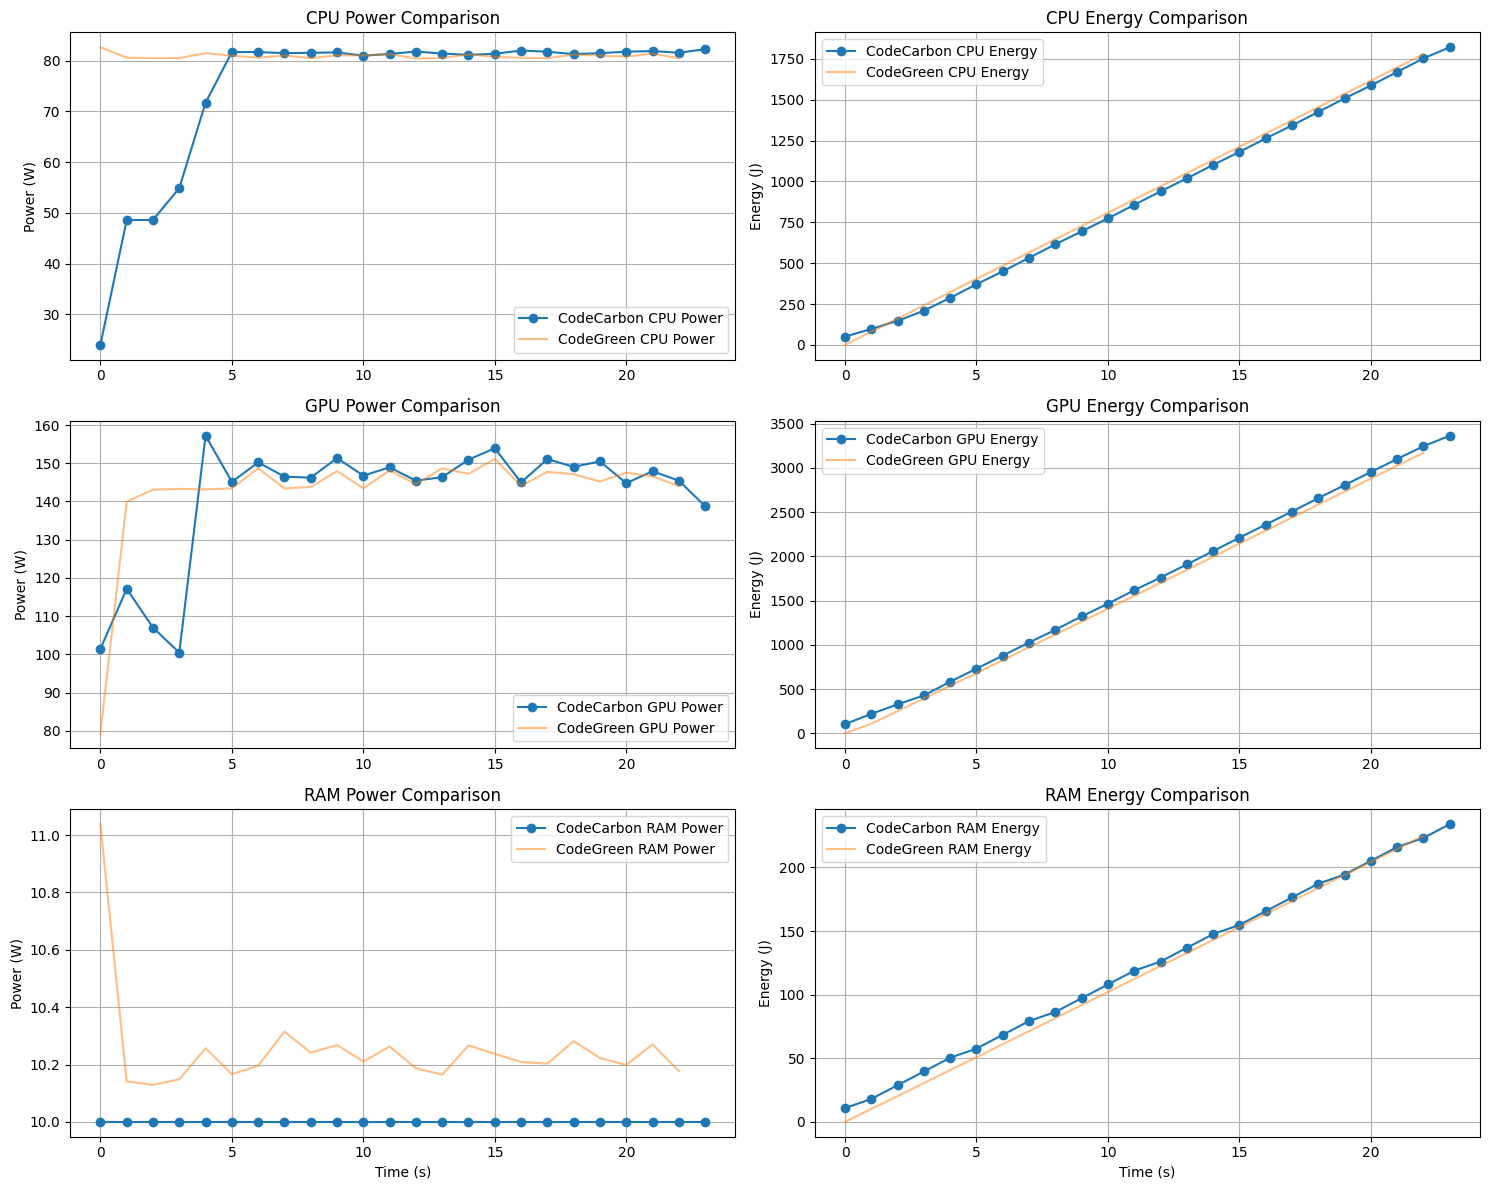

In [2]:
import json
import re
from datetime import datetime
import matplotlib.pyplot as plt

def parse_codecarbon(log_file):
    cc_data = {
        "time": [],
        "ram_power": [], "ram_energy": [],
        "cpu_power": [], "cpu_energy": [],
        "gpu_power": [], "gpu_energy": []
    }
    
    time_fmt = "%Y-%m-%d %H:%M:%S,%f"
    current_time = None
    
    with open(log_file, "r") as f:
        for line in f:
            match_time = re.match(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3})", line)
            if match_time:
                current_time = datetime.strptime(match_time.group(1), time_fmt).timestamp()
                current_time = round(current_time) # group by second
                
                if len(cc_data["time"]) == 0 or cc_data["time"][-1] != current_time:
                     cc_data["time"].append(current_time)
                     cc_data["ram_power"].append(None)
                     cc_data["ram_energy"].append(None)
                     cc_data["cpu_power"].append(None)
                     cc_data["cpu_energy"].append(None)
                     cc_data["gpu_power"].append(None)
                     cc_data["gpu_energy"].append(None)
            else:
                continue

            idx = -1

            if "RAM Power" in line:
                m = re.search(r"Energy consumed for RAM : ([\d.]+) kWh.*RAM Power : ([\d.]+) W", line)
                if m:
                    cc_data["ram_energy"][idx] = float(m.group(1)) * 3.6e6
                    cc_data["ram_power"][idx] = float(m.group(2))
                    
            elif "Energy consumed for All CPU" in line:
                m = re.search(r"Energy consumed for All CPU : ([\d.]+) kWh", line)
                if m:
                    cc_data["cpu_energy"][idx] = float(m.group(1)) * 3.6e6

            elif "Delta energy consumed for CPU" in line:
                m = re.search(r"Delta energy consumed for CPU .* power : ([\d.]+) W", line)
                if m:
                    cc_data["cpu_power"][idx] = float(m.group(1))
                    
            elif "Total GPU Power" in line:
                m = re.search(r"Energy consumed for all GPUs : ([\d.]+) kWh.*Total GPU Power : ([\d.]+) W", line)
                if m:
                    cc_data["gpu_energy"][idx] = float(m.group(1)) * 3.6e6
                    cc_data["gpu_power"][idx] = float(m.group(2))
                    
    for k in cc_data:
        cc_data[k] = [x if x is not None else 0.0 for x in cc_data[k]]
        
    return cc_data
def parse_codegreen(json_file):
    with open(json_file, "r") as f:
        cg_json = json.load(f)
        
    inference_task = next((t for t in cg_json["tasks"] if t["name"] == "instances_inference"), None)
    if not inference_task or len(inference_task["timeseries"]) == 0:
        return None
        
    cg_data = {
        "time": [],
        "ram_power": [], "ram_energy": [],
        "cpu_power": [], "cpu_energy": [],
        "gpu_power": [], "gpu_energy": []
    }
    
    # Grab the baseline cumulative values from the first entry to zero out the start
    first_entry = inference_task["timeseries"][0]
    first_cpu_j = sum(v for k, v in first_entry["domain_j"].items() if k.startswith("package"))
    first_gpu_j = sum(v for k, v in first_entry["domain_j"].items() if k.startswith("gpu"))
    first_ram_j = first_entry["domain_j"].get("dram", 0)

    for entry in inference_task["timeseries"]:
        cg_data["time"].append(entry["t_ns"] / 1e9)
        
        # Power (W) - Instantaneous/Average for the tick
        cpu_w = sum(v for k, v in entry["domain_w"].items() if k.startswith("package"))
        gpu_w = sum(v for k, v in entry["domain_w"].items() if k.startswith("gpu"))
        ram_w = entry["domain_w"].get("dram", 0)
        
        cg_data["cpu_power"].append(cpu_w)
        cg_data["gpu_power"].append(gpu_w)
        cg_data["ram_power"].append(ram_w)
        
        # Energy (J) - Subtract the first entry's Joules to start the plot at 0
        cpu_j = sum(v for k, v in entry["domain_j"].items() if k.startswith("package"))
        gpu_j = sum(v for k, v in entry["domain_j"].items() if k.startswith("gpu"))
        ram_j = entry["domain_j"].get("dram", 0)
        
        cg_data["cpu_energy"].append(cpu_j - first_cpu_j)
        cg_data["gpu_energy"].append(gpu_j - first_gpu_j)
        cg_data["ram_energy"].append(ram_j - first_ram_j)
        
    return cg_data

cc_log_file = "lm_eval/codecarbon_log/livecodebench/Qwen2.5-Coder-1.5B/instances_inference.log"
cg_json_file = "lm_eval/codegreen_log/livecodebench/Qwen2.5-Coder-1.5B/codegreen.json"

cc_data = parse_codecarbon(cc_log_file)
cg_data = parse_codegreen(cg_json_file)

# Normalize time to start from 0 for fair comparison
cc_t0 = cc_data["time"][0] if cc_data["time"] else 0
cg_t0 = cg_data["time"][0] if cg_data["time"] else 0

cc_time = [t - cc_t0 for t in cc_data["time"]]
cg_time = [t - cg_t0 for t in cg_data["time"]]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# POWER PLOTS
axes[0, 0].plot(cc_time, cc_data["cpu_power"], label='CodeCarbon CPU Power', marker='o')
axes[0, 0].plot(cg_time, cg_data["cpu_power"], label='CodeGreen CPU Power', alpha=0.5)
axes[0, 0].set_title('CPU Power Comparison')
axes[0, 0].set_ylabel('Power (W)')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[1, 0].plot(cc_time, cc_data["gpu_power"], label='CodeCarbon GPU Power', marker='o')
axes[1, 0].plot(cg_time, cg_data["gpu_power"], label='CodeGreen GPU Power', alpha=0.5)
axes[1, 0].set_title('GPU Power Comparison')
axes[1, 0].set_ylabel('Power (W)')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[2, 0].plot(cc_time, cc_data["ram_power"], label='CodeCarbon RAM Power', marker='o')
axes[2, 0].plot(cg_time, cg_data["ram_power"], label='CodeGreen RAM Power', alpha=0.5)
axes[2, 0].set_title('RAM Power Comparison')
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('Power (W)')
axes[2, 0].legend()
axes[2, 0].grid(True)

# ENERGY PLOTS (cumulative)
axes[0, 1].plot(cc_time, cc_data["cpu_energy"], label='CodeCarbon CPU Energy', marker='o')
axes[0, 1].plot(cg_time, cg_data["cpu_energy"], label='CodeGreen CPU Energy', alpha=0.5)
axes[0, 1].set_title('CPU Energy Comparison')
axes[0, 1].set_ylabel('Energy (J)')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 1].plot(cc_time, cc_data["gpu_energy"], label='CodeCarbon GPU Energy', marker='o')
axes[1, 1].plot(cg_time, cg_data["gpu_energy"], label='CodeGreen GPU Energy', alpha=0.5)
axes[1, 1].set_title('GPU Energy Comparison')
axes[1, 1].set_ylabel('Energy (J)')
axes[1, 1].legend()
axes[1, 1].grid(True)

axes[2, 1].plot(cc_time, cc_data["ram_energy"], label='CodeCarbon RAM Energy', marker='o')
axes[2, 1].plot(cg_time, cg_data["ram_energy"], label='CodeGreen RAM Energy', alpha=0.5)
axes[2, 1].set_title('RAM Energy Comparison')
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].set_ylabel('Energy (J)')
axes[2, 1].legend()
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()



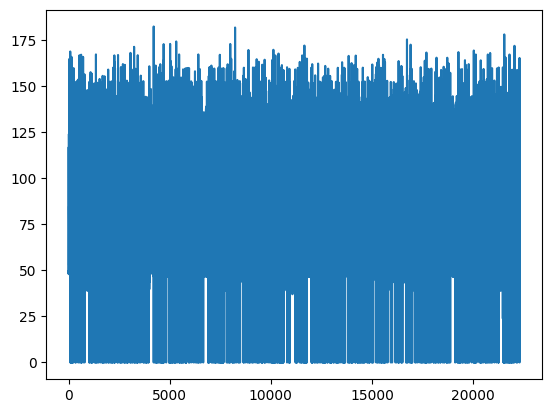

In [2]:
with open(cg_json_file, "r") as f:
    my_file = json.load(f)

inference_task = next((t for t in my_file["tasks"] if t["name"] == "instances_inference"), None)
cpu_power = [x["domain_w"]["package-0"] for x in inference_task["timeseries"]]
plt.plot(cpu_power)